# 03 - Modélisation, le journal de progression

Ce notebook n'est pas une présentation du résultat final, c'est le **brouillon** qui montre comment
on est passé d'un modèle moyen à un modèle correct. À chaque étape : ce qu'on a essayé, ce qu'on a
observé, et ce que ça nous a poussé à faire ensuite.

La cible reste la même : `arr_del15`, le retard à l'arrivée d'au moins 15 minutes, prédit avec des
variables connues **avant** le vol.


In [1]:
import duckdb, pandas as pd, numpy as np, joblib, json, matplotlib.pyplot as plt
%matplotlib inline
from sklearn.metrics import roc_curve, auc, mean_absolute_error
db = duckdb.connect("../data/processed/flights.duckdb", read_only=True)
meta = json.load(open("../models/meta.json"))
print("features réservation :", meta["features"])
print("features jour du vol :", meta["dayof_features"])

features réservation : ['airline', 'origin', 'dest', 'route', 'orig_hour', 'month', 'day_of_week', 'dep_hour', 'distance', 'crs_elapsed', 'prcp', 'snow', 'wspd', 'tavg']
features jour du vol : ['airline', 'origin', 'dest', 'route', 'orig_hour', 'month', 'day_of_week', 'dep_hour', 'distance', 'crs_elapsed', 'prcp', 'snow', 'wspd', 'tavg', 'prev_arr_delay', 'dep_congestion', 'turnaround', 'airport_state']


## Étape 1, les trois premiers modèles

On commence simple : un modèle de référence (prédit toujours à l'heure), une régression logistique,
et un gradient boosting. Découpage **temporel** (janvier-octobre pour entraîner, novembre-décembre
pour tester) pour ne jamais prédire le passé avec le futur. Voici les scores obtenus (calculés par
`src/train.py`).

In [2]:
pd.read_csv("../models/resultats.csv")

,modele,AUC,PR_AUC,F1,accuracy,t_train_s
0,Dummy (majoritaire),0.5000,0.1795,0.0000,0.8205,NaN
1,Regression logistique,0.5553,0.2094,0.2926,0.5483,10.4
2,HistGradientBoosting,0.6494,0.2970,0.3185,0.7414,69.0


Lecture : le Dummy atteint 82 % d'accuracy mais AUC 0,50, ce qui confirme que l'accuracy est
trompeuse. Le gradient boosting est le meilleur à **0,65** d'AUC. C'est mieux que le hasard, mais on
sentait qu'il ratait beaucoup de vols.

## Étape 2, la leçon sur la calibration

Notre toute première version utilisait `class_weight="balanced"` pour compenser le déséquilibre.
Résultat, elle annonçait en moyenne bien plus de retard que la réalité. On a vérifié, puis retiré
cette option pour que les probabilités soient justes. C'est une étape qu'on garde ici parce qu'elle
fait partie du chemin.

In [3]:
model = joblib.load("../models/model.joblib")
feat = meta["features"]
def load_test(cols_extra=""):
    df = db.execute(f'''SELECT f.airline,f.origin,f.dest,f.month,f.day_of_week,f.dep_hour,f.distance,f.crs_elapsed,
        f.prev_arr_delay,f.dep_congestion,f.turnaround,f.airport_state,
        w.prcp,w.snow,w.wspd,w.tavg,f.arr_del15,f.arr_delay {cols_extra}
        FROM flights f LEFT JOIN weather w ON f.origin=w.iata AND f.flight_date=w.date
        WHERE f.flight_date>='2024-11-01' AND f.cancelled=0 AND f.diverted=0
          AND f.arr_del15 IS NOT NULL AND f.crs_elapsed IS NOT NULL USING SAMPLE 250000 ROWS''').df()
    df["route"]=df.origin+"_"+df.dest; df["orig_hour"]=df.origin+"_"+df.dep_hour.astype(str)
    for c in ["prcp","snow"]: df[c]=df[c].fillna(0)
    for c in ["wspd","tavg"]: df[c]=df[c].fillna(df[c].median())
    return df
test = load_test()
proba_resa = model.predict_proba(test[feat])[:,1]
print("réservation, proba moyenne prédite : %.3f  vs  retard réel : %.3f" % (proba_resa.mean(), test.arr_del15.mean()))

réservation, proba moyenne prédite : 0.154  vs  retard réel : 0.177


Les deux chiffres sont proches : le modèle sans pondération est bien **calibré**, quand il dit
un pourcentage, la réalité tombe autour.

## Étape 3, pourquoi ça plafonne, et ce que fait le marché

Le modèle stagnait autour de 0,65. On s'est demandé pourquoi il ratait autant, et on a regardé
comment font les services précis (Google Flights, FlightAware). Ils prédisent non pas à la
réservation mais **le jour du vol**, avec des données du moment. On a donc cherché, dans nos propres
données, des variables connues juste avant le départ. Trois pistes, qu'on vérifie ici par leur
corrélation avec le retard.

In [4]:
s = db.execute('''SELECT prev_arr_delay, dep_congestion, turnaround, airport_state, arr_del15
    FROM flights WHERE cancelled=0 AND arr_del15 IS NOT NULL USING SAMPLE 400000 ROWS''').df()
for col in ["prev_arr_delay","dep_congestion","turnaround","airport_state"]:
    print("corr(%s, retard) = %.3f" % (col, s[[col,"arr_del15"]].corr().iloc[0,1]))

corr(prev_arr_delay, retard) = 0.320
corr(dep_congestion, retard) = 0.035
corr(turnaround, retard) = -0.062
corr(airport_state, retard) = 0.274


La propagation (retard de l'avion précédent) et l'état du réseau ressortent nettement, bien plus
que les variables de calendrier vues avant. Ce sont elles qui manquaient.

## Étape 4, la progression du score

En ajoutant ces variables une par une (via `src/train_dayof.py`), le score est monté à chaque fois :

| Modèle | AUC |
|---|---|
| Gradient boosting + météo (réservation) | 0,65 |
| + propagation de l'avion précédent | 0,775 |
| + congestion et temps d'escale | 0,793 |
| + état du réseau | **0,80** |

On vérifie le modèle final du jour du vol sur le jeu de test.

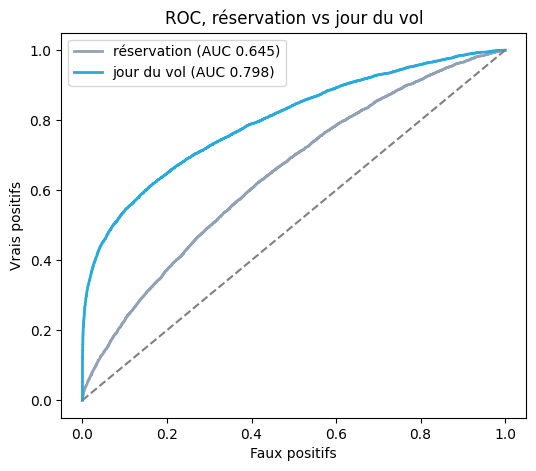

In [5]:
do = joblib.load("../models/model_dayof.joblib")
dfeat = meta["dayof_features"]
proba_jour = do.predict_proba(test[dfeat])[:,1]
fpr_r,tpr_r,_ = roc_curve(test.arr_del15, proba_resa)
fpr_j,tpr_j,_ = roc_curve(test.arr_del15, proba_jour)
plt.figure(figsize=(6,5))
plt.plot(fpr_r,tpr_r,color="#93a1b5",lw=2,label=f"réservation (AUC {auc(fpr_r,tpr_r):.3f})")
plt.plot(fpr_j,tpr_j,color="#2aa9db",lw=2,label=f"jour du vol (AUC {auc(fpr_j,tpr_j):.3f})")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Faux positifs"); plt.ylabel("Vrais positifs"); plt.title("ROC, réservation vs jour du vol"); plt.legend(); plt.show()

La courbe du jour du vol domine clairement celle de la réservation : les variables ajoutées
apportent une vraie information.

## Étape 5, le modèle est-il honnête ? (calibration)

On regroupe les vols par niveau de risque prédit et on compare au retard réel de chaque groupe. Si
les points suivent la diagonale, le modèle tient ses promesses.

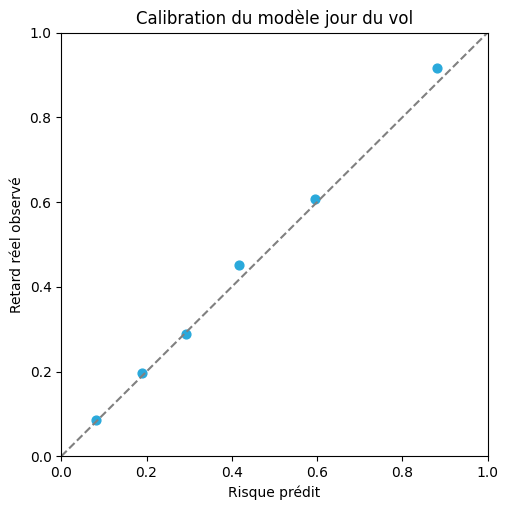

,pred,reel,n
"(0.0, 0.15]",0.080,0.085,28986
"(0.15, 0.25]",0.189,0.197,5399
"(0.25, 0.35]",0.293,0.288,1895
"(0.35, 0.5]",0.417,0.451,1438
"(0.5, 0.7]",0.595,0.607,1059
"(0.7, 1.01]",0.882,0.917,2025


In [6]:
bins = [0,.15,.25,.35,.5,.7,1.01]
cats = pd.cut(proba_jour, bins)
cal = pd.DataFrame({"p":proba_jour,"r":test.arr_del15.values}).groupby(cats, observed=True).agg(pred=("p","mean"), reel=("r","mean"), n=("r","size"))
plt.figure(figsize=(5.5,5.5))
plt.plot([0,1],[0,1],"--",color="gray")
plt.scatter(cal.pred, cal.reel, s=40, color="#2aa9db")
plt.xlabel("Risque prédit"); plt.ylabel("Retard réel observé"); plt.title("Calibration du modèle jour du vol")
plt.xlim(0,1); plt.ylim(0,1); plt.show()
cal.round(3)

## Étape 6, prédire des minutes, et le piège de la moyenne

En plus du risque en pourcentage, on a voulu une prévision en minutes. Une régression prédisait
d'abord la **moyenne**, gonflée par les rares très gros retards, donc alarmiste. On est passé à la
**médiane** (le retard du vol typique).

In [7]:
reg = joblib.load("../models/model_dayof_reg.joblib")
rf = meta["dayof_reg_features"]
pred_min = reg.predict(test[rf])
mae = mean_absolute_error(test.arr_delay.clip(-30,240), pred_min)
print("erreur moyenne du régresseur jour du vol : %.1f min" % mae)
print("médiane des minutes prédites : %.0f min (le vol typique est proche de l'heure)" % np.median(pred_min))

erreur moyenne du régresseur jour du vol : 15.5 min
médiane des minutes prédites : -10 min (le vol typique est proche de l'heure)


## Étape 7, le non supervisé

En parallèle, un clustering (KMeans) regroupe les aéroports par profil et une détection d'anomalies
(IsolationForest) repère les cas atypiques. Résultats produits par `src/unsupervised.py`.

In [8]:
cl = pd.read_csv("../models/airport_clusters.csv")
print("profil moyen par cluster :")
print(cl.groupby("cluster")[["n_flights","delay_rate","avg_delay","avg_distance"]].mean().round(2))
print("\naéroports atypiques :", cl[cl.anomalie==1].iata.tolist())

profil moyen par cluster :
         n_flights  delay_rate  avg_delay  avg_distance
cluster                                                
0         18733.25        0.19       6.52        580.89
1         33191.58        0.15       2.35        826.16
2         34330.82        0.24      12.39        909.06
3        166032.04        0.22       7.16        915.35

aéroports atypiques : ['OGG', 'SJU', 'ASE', 'DFW', 'CLT', 'EYW', 'ITO']


## Ce qu'on retient du chemin

On est parti de 0,65 à la réservation, on a compris pourquoi ça plafonnait (les causes du jour ne
sont pas dans les données de réservation), on est allé chercher trois variables connues juste avant
le vol, et on est monté à **0,80**, au niveau de FlightAware. Le modèle reste calibré et honnête sur
ses limites. La progression, plus que le score final, est le vrai résultat de ce travail.